<a href="https://colab.research.google.com/github/vituhaa/smile-detection/blob/main/smile_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import warnings, zipfile, os, seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Activation, Dropout, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

In [3]:
# # выполняется один раз
# zip_path = '/content/drive/MyDrive/Smile-Classification.v1i.folder.zip'
# extract_path = '/content/drive/MyDrive/smile_ds'

# with zipfile.ZipFile(zip_path, 'r') as zip_ds:
#   zip_ds.extractall(extract_path)
#   print("датасет скачан")

датасет скачан


In [4]:
TRAIN_PATH = os.path.join('/content/drive/MyDrive/smile_ds/train')
VAL_PATH = os.path.join('/content/drive/MyDrive/smile_ds/valid')
TEST_PATH = os.path.join('/content/drive/MyDrive/smile_ds/test')

In [5]:
train_gen = ImageDataGenerator(rescale=1/255)
train_data = train_gen.flow_from_directory(
    TRAIN_PATH,
    target_size=(64, 64),
    class_mode='binary',
    color_mode='grayscale'
)

val_gen = ImageDataGenerator(rescale=1/255)
val_data = val_gen.flow_from_directory(
    VAL_PATH,
    target_size=(64, 64),
    class_mode='binary',
    color_mode='grayscale'
)

test_gen = ImageDataGenerator(rescale=1/255)
test_data = test_gen.flow_from_directory(
    TEST_PATH,
    target_size=(64, 64),
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

Found 9210 images belonging to 2 classes.
Found 2632 images belonging to 2 classes.
Found 1316 images belonging to 2 classes.


In [6]:
model_baseline = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(64, 64, 1)),
    MaxPool2D(2, 2),
    Conv2D(64, (3, 3), padding='same'),
    MaxPool2D(2, 2),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model_baseline.compile(loss='binary_crossentropy',
                       optimizer='adam',
                       metrics=['accuracy', 'precision', 'recall'])

model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,201 (137.50 KB)

 Trainable params: 35,201 (137.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history_baseline = model_baseline.fit(train_data, epochs=10, validation_data=val_data, batch_size=40)

Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 106s 337ms/step - accuracy: 0.8246 - loss: 0.3922 - precision: 0.7808 - recall: 0.5177 - val_accuracy: 0.8689 - val_loss: 0.3034 - val_precision: 0.7923 - val_recall: 0.7226
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 79s 274ms/step - accuracy: 0.8913 - loss: 0.2679 - precision: 0.8475 - recall: 0.7450 - val_accuracy: 0.8701 - val_loss: 0.3277 - val_precision: 0.9287 - val_recall: 0.5819
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 91s 315ms/step - accuracy: 0.9013 - loss: 0.2469 - precision: 0.8574 - recall: 0.7757 - val_accuracy: 0.8944 - val_loss: 0.2650 - val_precision: 0.8823 - val_recall: 0.7199
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 97s 337ms/step - accuracy: 0.9075 - loss: 0.2301 - precision: 0.8605 - recall: 0.7983 - val_accuracy: 0.8989 - val_loss: 0.2612 - val_precision: 0.8374 - val_recall: 0.7943
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 140s 330ms/step - accuracy: 0.9110 - loss: 0.2180 - precision: 0.8648 - recall: 0.8076 - val_accuracy: 0.89

In [9]:
model_baseline.save('model_baseline.h5')

In [10]:
loss, acc, precision, recall = model_baseline.evaluate(test_data)
print("Loss: ", loss, '\n',
      "Accuracy: ", acc, '\n',
      "Precision: ", precision, '\n',
      "Recall: ", recall)

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.8951 - loss: 0.2596 - precision: 0.8117 - recall: 0.8204
Loss:  0.2595761716365814 
 Accuracy:  0.8951367735862732 
 Precision:  0.8116710782051086 
 Recall:  0.8203753232955933


42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step
[[872  71]
 [ 67 306]]
              precision    recall  f1-score   support

    negative       0.93      0.92      0.93       943
    positive       0.81      0.82      0.82       373

    accuracy                           0.90      1316
   macro avg       0.87      0.87      0.87      1316
weighted avg       0.90      0.90      0.90      1316



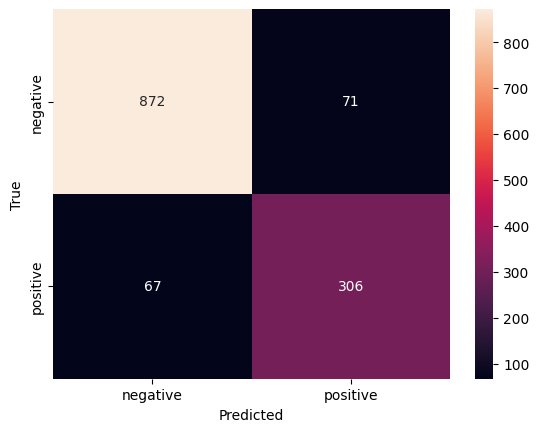

In [11]:
probs = model_baseline.predict(test_data)
y_pred = (probs > 0.5).astype(int).ravel()
y_true = test_data.classes

matrix = confusion_matrix(y_true, y_pred)
print(matrix)
print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

sns.heatmap(matrix, annot=True, fmt='d',
            xticklabels=["negative", "positive"],
            yticklabels=["negative", "positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Модель сложнее

In [13]:
filter_size = (3, 3)

model_second = Sequential([
    Conv2D(32, filter_size, padding='same', activation='relu', input_shape=(64, 64, 1)),
    MaxPool2D(2, 2),
    Conv2D(64, filter_size, padding='same', activation='relu'),
    MaxPool2D(2, 2),
    Conv2D(128, filter_size, padding='same', activation='relu'),
    MaxPool2D(2, 2),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model_second.compile(loss='binary_crossentropy',
                       optimizer=optimizer,
                       metrics=['accuracy', 'precision', 'recall'])

model_second.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,256,129 (8.61 MB)

 Trainable params: 2,256,129 (8.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_second = model_second.fit(train_data, epochs=10, validation_data=val_data, batch_size=40)

In [15]:
loss, acc, precision, recall = model_second.evaluate(test_data)
print("Loss: ", loss, '\n',
      "Accuracy: ", acc, '\n',
      "Precision: ", precision, '\n',
      "Recall: ", recall)

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.9172 - loss: 0.2211 - precision: 0.8860 - recall: 0.8123
Loss:  0.22114180028438568 
 Accuracy:  0.9171732664108276 
 Precision:  0.8859649300575256 
 Recall:  0.8123324513435364


42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 164ms/step
[[904  39]
 [ 70 303]]
              precision    recall  f1-score   support

    negative       0.93      0.96      0.94       943
    positive       0.89      0.81      0.85       373

    accuracy                           0.92      1316
   macro avg       0.91      0.89      0.90      1316
weighted avg       0.92      0.92      0.92      1316



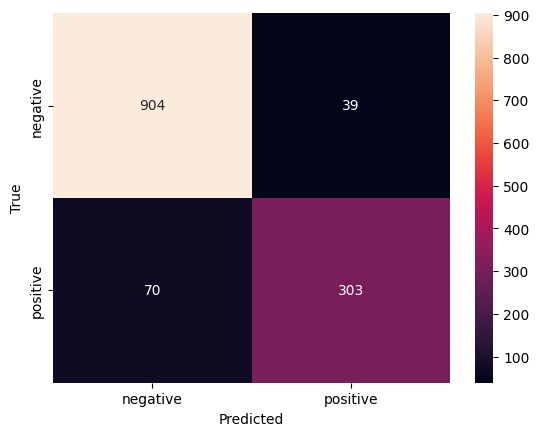

In [16]:
probs = model_second.predict(test_data)
y_pred = (probs > 0.5).astype(int).ravel()
y_true = test_data.classes

matrix = confusion_matrix(y_true, y_pred)
print(matrix)
print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

sns.heatmap(matrix, annot=True, fmt='d',
            xticklabels=["negative", "positive"],
            yticklabels=["negative", "positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()